# 04_10 Clustering - BisectingKMeans
Train and evaluate BisectingKMeans.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train BisectingKMeans va xem phan bo cluster de so sanh voi KMeans.
- Muc tieu ky thuat: Hien thi bang metric va bieu do cluster size ngay tren notebook.

26/03/31 22:25:52 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:25:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/31 22:25:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 22:25:54 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 22:25:54 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


26/03/31 22:26:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/31 22:26:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


{'model_family': 'clustering', 'model_name': 'BisectingKMeans', 'silhouette': 0.0024415901834747202, 'rows': 96096, 'k': 6}


,model_family,model_name,silhouette,rows,k
0,clustering,BisectingKMeans,0.002442,96096,6


,prediction,count
0,0,24153
1,1,16141
2,2,16530
3,3,6826
4,4,20625
5,5,11821


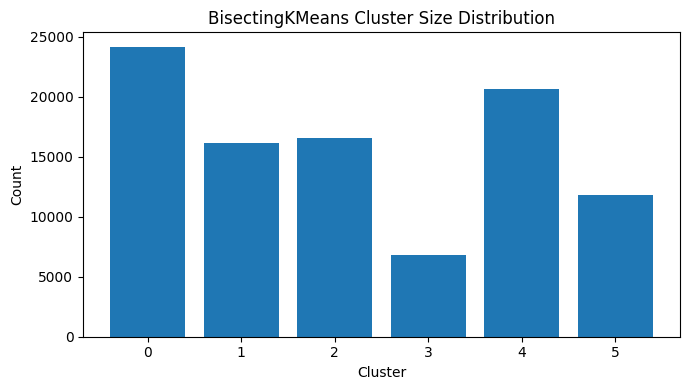

135

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pyspark.sql import SparkSession
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
spark=(SparkSession.builder.appName('04_10_bkm').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'clustering'/'bisecting_kmeans'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
df=spark.read.parquet(str(FEATURE_DIR/'clustering_fe')).select('customer_unique_id','features').dropna()
bkm=BisectingKMeans(featuresCol='features',predictionCol='prediction',k=6,maxIter=50,seed=42)
m=bkm.fit(df)
pred=m.transform(df)
sil=ClusteringEvaluator(featuresCol='features',predictionCol='prediction',metricName='silhouette').evaluate(pred)
metrics={'model_family':'clustering','model_name':'BisectingKMeans','silhouette':float(sil),'rows':df.count(),'k':6}
print(metrics)
display(pd.DataFrame([metrics]))
cluster_pdf=pred.groupBy('prediction').count().orderBy('prediction').toPandas()
if not cluster_pdf.empty:
    display(cluster_pdf)
    plt.figure(figsize=(7,4))
    plt.bar(cluster_pdf['prediction'].astype(str), cluster_pdf['count'])
    plt.title('BisectingKMeans Cluster Size Distribution')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'clustering_bisecting_kmeans.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')